# Practical 02: Multivariable Linear Regression

In [31]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import datasets


## Load Dataset

In [32]:

data = datasets.fetch_california_housing()
X = data.data
y = data.target

print("Feature Names:", data.feature_names)
print("Shape of X:", X.shape)
print("Shape of Y:", y.shape)


Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape of X: (20640, 8)
Shape of Y: (20640,)


## Train-Test Split

In [33]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Method 1: sklearn LinearRegression

In [34]:

model = LinearRegression()
model.fit(X_train, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predictions

In [35]:

Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)


## Model Evaluation

In [36]:

train_mse = mean_squared_error(Y_train, Y_train_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)

train_r2 = r2_score(Y_train, Y_train_pred)
test_r2 = r2_score(Y_test, Y_test_pred)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)
print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)


Training MSE: 0.5179331255246697
Testing MSE: 0.5558915986952425
Training R2 Score: 0.6125511913966952
Testing R2 Score: 0.5757877060324521


## Feature Coefficient Interpretation

In [37]:

print("Feature Coefficients:")
for feature, coef in zip(data.feature_names, model.coef_):
    print(feature, ":", coef)

print("Intercept:", model.intercept_)


Feature Coefficients:
MedInc : 0.44867490966571894
HouseAge : 0.009724257517905413
AveRooms : -0.12332334282795913
AveBedrms : 0.7831449067929733
Population : -2.029620580143443e-06
AveOccup : -0.0035263184871342293
Latitude : -0.41979248658835716
Longitude : -0.4337080649639876
Intercept: -37.02327770606397


## Method 2: Gradient Descent

In [38]:
X_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
theta = np.zeros(X_b.shape[1])

learning_rate = 0.01
iterations = 1000
m = X_b.shape[0]

for i in range(iterations):
    gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - Y_train)
    theta = theta - learning_rate * gradients

print("Gradient Descent Parameters:")
print(theta)


Gradient Descent Parameters:
[nan nan nan nan nan nan nan nan nan]


C:\Users\himan\AppData\Local\Temp\ipykernel_9924\5696627.py:9: RuntimeWarning: overflow encountered in dot
  gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - Y_train)
C:\Users\himan\AppData\Local\Temp\ipykernel_9924\5696627.py:10: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradients


## Gradient Descent Predictions

In [39]:

X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]
Y_pred_gd = X_test_b.dot(theta)

print("First 10 Predictions (Gradient Descent):")
print(Y_pred_gd[:10])


First 10 Predictions (Gradient Descent):
[nan nan nan nan nan nan nan nan nan nan]


## Visualization: Actual vs Predicted

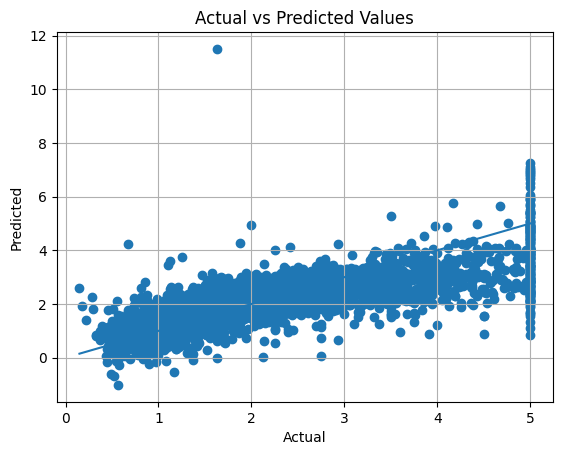

In [40]:

plt.scatter(Y_test, Y_test_pred)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()
